In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")
from skrmt.denoise.mp_pca import MarchenkoPasturPCADenoiser

In [5]:
def plot_slices(slices, titles=None, cmap="gray", origin="lower"):
    """Function to display a row of image slices."""
    n_slices = len(slices)
    fig, axes = plt.subplots(1, n_slices, figsize=(3.5 * n_slices, 3.8))

    if len(slices) > 1:
        for i, slice_array in enumerate(slices):
            axes[i].imshow(slice_array, cmap=cmap, origin=origin, aspect="auto")
            if titles is not None:
                axes[i].set_title(titles[i])
            axes[i].grid(False)
    else:
        axes.imshow(slices[0], cmap=cmap, origin=origin)
        if titles is not None:
            axes.set_title(titles[0])
        axes.grid(False)

In [6]:
tumor_slice = np.load("sim_data/sample_tumor_img.npy")
tumor_slice.shape

(184, 132)

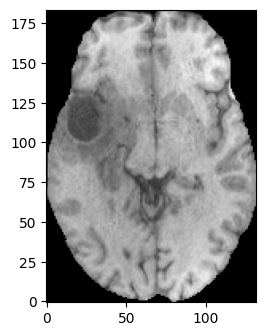

In [7]:
plot_slices([tumor_slice])

In [8]:
pad_tumor_slice = np.pad(tumor_slice, pad_width=5, mode="constant", constant_values=0)
pad_tumor_slice.shape

(194, 142)

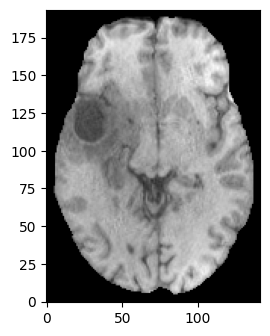

In [9]:
# Title: "Original brain slice"
plot_slices([pad_tumor_slice])

In [10]:
from denoise_rmt import ImgNoiseCorruptor

noise_corruptor = ImgNoiseCorruptor(original_img=pad_tumor_slice)

In [11]:
# Simulation parameters
n_snapshots = 100
random_seed = 1

# Noise parameters
sigma = 35  # Marchenko-Pastur sigma ~ noise standard deviation
rice_b = 2  # Rice distribution parameter

# Generate noisy snapshot and foreground mask
snapshots, fg_masks = noise_corruptor.generate_rician_noisy_displaced_imgs(
    n_snapshots=n_snapshots,
    rice_b=rice_b,
    sigma=sigma,
    seed=random_seed,
)
snapshot = snapshots[0]
fg_mask = fg_masks[0]

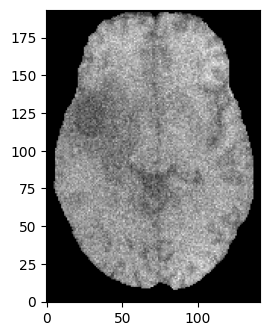

In [12]:
# Title: "Sample of corrupted image"
plot_slices([snapshot])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'median' -> sigma_ = 28.8463, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


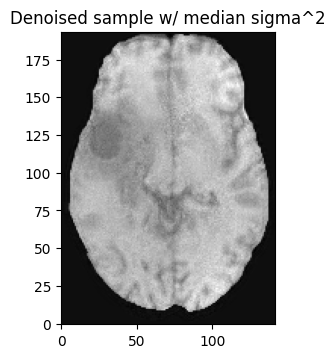

In [13]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="median")

denoised_snapshots_median = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_median.shape}")
plot_slices([denoised_snapshots_median[0]], titles=["Denoised sample w/ median sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'bulk_mean' -> sigma_ = 200.066, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


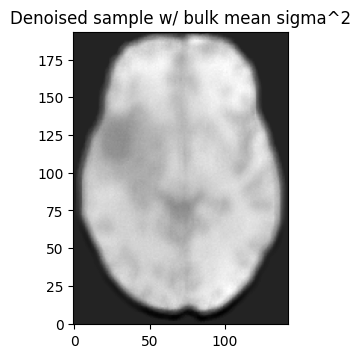

In [14]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="bulk_mean")

denoised_snapshots_bulk_mean = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_bulk_mean.shape}")
plot_slices([denoised_snapshots_bulk_mean[0]], titles=["Denoised sample w/ bulk mean sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'min_eigen' -> sigma_ = 26.8983, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


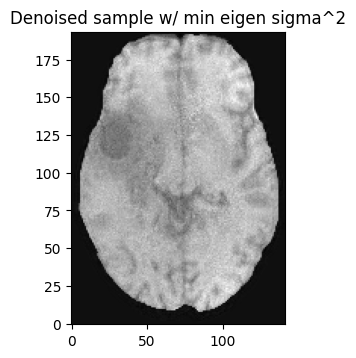

In [15]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="min_eigen")

denoised_snapshots_min_eigen = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_min_eigen.shape}")
plot_slices([denoised_snapshots_min_eigen[0]], titles=["Denoised sample w/ min eigen sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'mp_fit' -> sigma_ = 26.4722, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


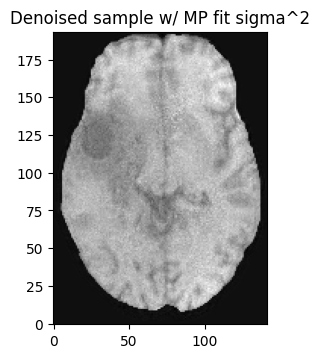

In [16]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="mp_fit")

denoised_snapshots_mp_fit = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_mp_fit.shape}")
plot_slices([denoised_snapshots_mp_fit[0]], titles=["Denoised sample w/ MP fit sigma^2"])

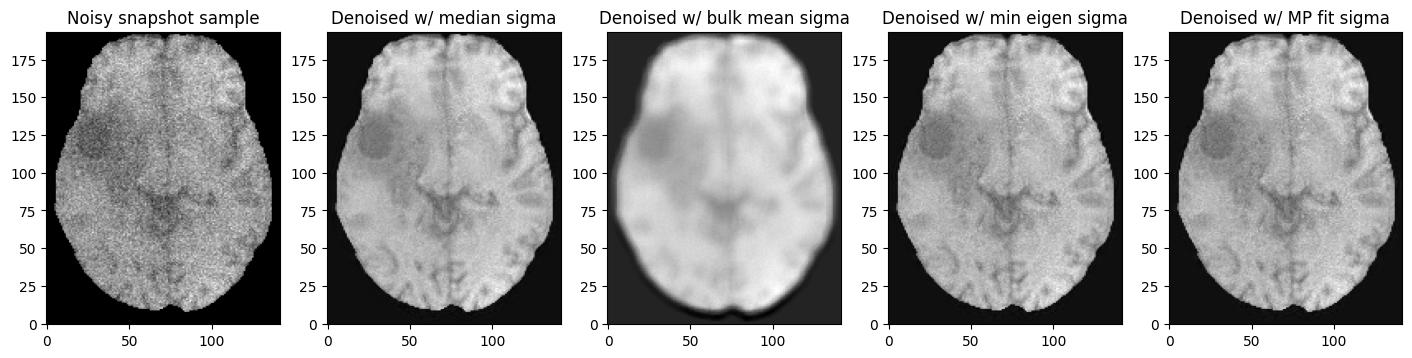

In [17]:
plot_slices(
    [
        snapshots[0],
        denoised_snapshots_median[0],
        denoised_snapshots_bulk_mean[0],
        denoised_snapshots_min_eigen[0],
        denoised_snapshots_mp_fit[0],
    ],
    titles=[
        "Noisy snapshot sample",
        "Denoised w/ median sigma",
        "Denoised w/ bulk mean sigma",
        "Denoised w/ min eigen sigma",
        "Denoised w/ MP fit sigma",
    ],
)